In [5]:
# =============================================================================
# EXPLORATORY DATA ANALYSIS: 2014-2016 EBOLA OUTBREAK DATA
# =============================================================================
#
# PURPOSE:
#   Initial exploration and quality assessment of the WHO Ebola surveillance
#   dataset before it is used for SEIR model fitting. This script is intended
#   to be run first in the pipeline to understand the raw data structure and
#   flag any issues that need to be handled during cleaning.
#
# STEPS:
#   1. Load the dataset and inspect its shape and structure
#   2. Filter records down to Liberia as our country of interest
#   3. Visualize cumulative cases and deaths over time
#   4. Audit data quality -- check for missing values and duplicate dates
#
# KEY FINDINGS:
#   - no nulls found, duplicate dates present but likely due to reporting practices (to be handled in cleaning)
#
# DATA:
#   Source file : ebola_2014_2016_clean.csv
#   Country     : Liberia
#   Columns used: Date,
#                 Cumulative no. of confirmed, probable and suspected cases,
#                 Cumulative no. of confirmed, probable and suspected deaths
# =============================================================================

In [6]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

(2485, 4)
        Country        Date  \
0        Guinea  2014-08-29   
1       Nigeria  2014-08-29   
2  Sierra Leone  2014-08-29   
3       Liberia  2014-08-29   
4  Sierra Leone  2014-09-05   

   Cumulative no. of confirmed, probable and suspected cases  \
0                                              648.0           
1                                               19.0           
2                                             1026.0           
3                                             1378.0           
4                                             1261.0           

   Cumulative no. of confirmed, probable and suspected deaths  
0                                              430.0           
1                                                7.0           
2                                              422.0           
3                                              694.0           
4                                              491.0           
(365, 4)
    Country        Date  

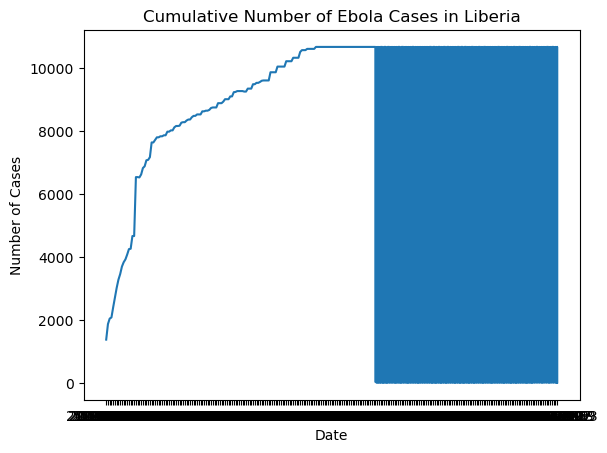

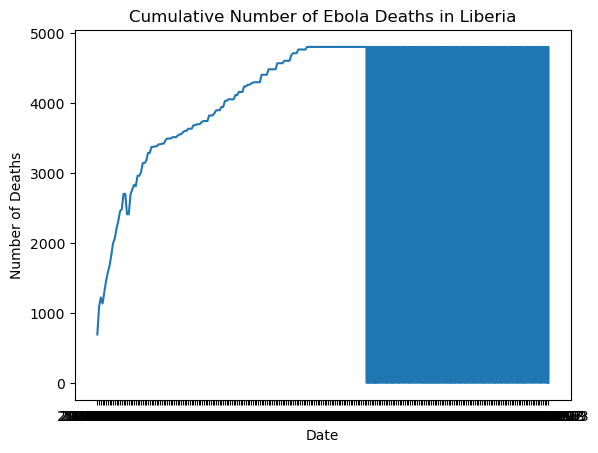

106
            Date  Cumulative no. of confirmed, probable and suspected cases  \
1329  2015-07-03                                            10666.0           
1336  2015-07-03                                               40.0           
1344  2015-07-06                                                4.0           
1349  2015-07-06                                            10666.0           
1353  2015-07-07                                                4.0           
...          ...                                                ...           
2465  2015-12-29                                            10666.0           
2466  2015-12-29                                                9.0           
2479  2016-03-23                                                9.0           
2480  2016-03-23                                            10666.0           
2482  2016-03-23                                                5.0           

      Cumulative no. of confirmed, probable and

In [7]:
# import data
df = pd.read_csv("ebola_2014_2016_clean.csv")

# inspect data
print(df.shape)
print(df.head())

# filter data for only Liberia
df_liberia = df[df["Country"] == "Liberia"]
print(df_liberia.shape)
print(df_liberia.head())
print(df_liberia.dtypes)
print(df_liberia.isnull().sum())

# create a line plot of the cumulative number of cases over time
plt.plot(df_liberia["Date"], df_liberia["Cumulative no. of confirmed, probable and suspected cases"])
plt.title("Cumulative Number of Ebola Cases in Liberia")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.show()

#create a line plot of the cumulative number of deaths over time
plt.plot(df_liberia["Date"], df_liberia["Cumulative no. of confirmed, probable and suspected deaths"])
plt.title("Cumulative Number of Ebola Deaths in Liberia")
plt.xlabel("Date")
plt.ylabel("Number of Deaths")
plt.show()

#check for duplicate dates 
print(df_liberia["Date"].duplicated().sum())

#print out the duplicate dates and the corresponding cumulative cases and deaths
print(df_liberia[df_liberia["Date"].duplicated(keep=False)][["Date", "Cumulative no. of confirmed, probable and suspected cases", "Cumulative no. of confirmed, probable and suspected deaths"]])
